Part B: Textual Data

**Dataset:** MTSamples Medical Transcriptions  
**Objective:** Data acquisition, cleaning (PHI removal), preprocessing and analysis on textual medical data

In [1]:
import kagglehub

path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
print("Path to dataset files:", path)

/home/sambhav/miniconda3/envs/mlenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 4.85M/4.85M [00:02<00:00, 2.47MB/s]

Extracting files...
Path to dataset files: /home/sambhav/.cache/kagglehub/datasets/tboyle10/medicaltranscriptions/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import string

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
csv_file = os.path.join(path, 'mtsamples.csv')
df = pd.read_csv(csv_file)
print(f"Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (4999, 6)
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [5]:
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [7]:
df.dtypes

Unnamed: 0            int64
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object

In [8]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")
print(f"Rows with missing transcription: {df['transcription'].isnull().sum()}")

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Total rows: 4999
Rows with missing transcription: 33


In [9]:
# Medical specialty distribution
print("Medical specialties:")
print(df['medical_specialty'].value_counts())

Medical specialties:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / 

In [10]:
# Sample transcription
print("Sample transcription:")
print("=" * 60)
print(df.iloc[0]['transcription'][:800])

Sample transcription:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pres


In [11]:
# Drop unnecessary column
df_clean = df.drop(columns=['Unnamed: 0'])

# Drop rows with missing transcription (we need text to analyze)
before = len(df_clean)
df_clean = df_clean.dropna(subset=['transcription'])
after = len(df_clean)

print(f"Dropped {before - after} rows with missing transcription")
print(f"Remaining rows: {after}")

Dropped 33 rows with missing transcription
Remaining rows: 4966


In [12]:
# Reset index
df_clean = df_clean.reset_index(drop=True)
print(f"Shape after cleaning: {df_clean.shape}")

Shape after cleaning: (4966, 5)


In [13]:
# Show some PHI patterns in the data
print("Looking for potential PHI in first 5 transcriptions...")
print("=" * 60)

for i in range(5):
    text = df_clean.iloc[i]['transcription']
    # Find capitalized words that might be names
    names = re.findall(r'\b([A-Z][a-z]+ [A-Z][a-z]+)\b', text)
    if names:
        print(f"Row {i}: Potential names found: {names[:5]}")

Looking for potential PHI in first 5 transcriptions...
Row 0: Potential names found: ['Ortho Tri']
Row 1: Potential names found: ['Lynn Holmberg', 'New York', 'Vital Signs']
Row 2: Potential names found: ['Slim Fast', 'Include Diovan']


In [14]:
def remove_phi(text):
    """Remove Protected Health Information from medical text."""
    if not isinstance(text, str):
        return text
    
    # Remove doctor names (Dr. XYZ, Dr. Firstname Lastname)
    text = re.sub(r'Dr\.?\s+[A-Z][a-z]+(\s+[A-Z][a-z]+)?', '[DOCTOR]', text)
    
    # Remove patient initials and names (e.g., "Mr. Smith", "Mrs. Jones")
    text = re.sub(r'\b(Mr\.|Mrs\.|Ms\.|Miss)\s+[A-Z][a-z]+(\s+[A-Z][a-z]+)?', '[PATIENT]', text)
    
    # Remove standalone initials like ABC, XYZ used as patient identifiers
    text = re.sub(r'\bI have seen [A-Z]+\b', 'I have seen [PATIENT]', text)
    text = re.sub(r'\bseen [A-Z]+ today\b', 'seen [PATIENT] today', text)
    
    # Remove dates (various formats)
    text = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', '[DATE]', text)
    text = re.sub(r'\b(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},?\s+\d{4}\b', '[DATE]', text)
    
    # Remove phone numbers
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '[PHONE]', text)
    
    # Remove SSN
    text = re.sub(r'\b\d{3}-\d{2}-\d{4}\b', '[SSN]', text)
    
    # Remove medical record numbers
    text = re.sub(r'\b(MRN|mrn)[:\s]+\d+\b', '[MRN]', text)
    
    # Remove specific city/state references (keep general ones)
    text = re.sub(r'\b(lives? in|from|located in|address) [A-Z][a-z]+(,? [A-Z][a-z]+)*\b', r'\1 [LOCATION]', text)
    
    return text

# Apply PHI removal
df_clean['transcription_clean'] = df_clean['transcription'].apply(remove_phi)

print("PHI removal applied.")
print(f"\nOriginal sample:")
print(df_clean.iloc[0]['transcription'][:300])
print(f"\nCleaned sample:")
print(df_clean.iloc[0]['transcription_clean'][:300])

PHI removal applied.

Original sample:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has us

Cleaned sample:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has us


In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
print(f"Loaded {len(stop_words)} stopwords")

Loaded 198 stopwords


In [16]:
def preprocess_text(text):
    """Clean and preprocess medical text."""
    if not isinstance(text, str):
        return ''
    
    # Lowercase
    text = text.lower()
    
    # Remove section headers like SUBJECTIVE:, OBJECTIVE:, etc.
    text = re.sub(r'\b(subjective|objective|assessment|plan|history|medications|allergies|vitals|review of systems|physical examination|impression|diagnosis|procedure|indication|findings|technique|results|discussion|recommendation)s?:?\b', '', text)
    
    # Remove numbers
    text = re.sub(r'\b\d+\.?\d*\b', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    return ' '.join(tokens)

df_clean['transcription_processed'] = df_clean['transcription_clean'].apply(preprocess_text)

print("Text preprocessing applied.")
print(f"\nProcessed sample:")
print(df_clean.iloc[0]['transcription_processed'][:400])

Text preprocessing applied.

Processed sample:
yearold white female presents complaint used lived seattle thinks worse past tried claritin zyrtec worked short time seemed lose effectiveness used allegra also used last summer began using two weeks ago appear working well used overthecounter sprays prescription nasal sprays asthma doest require daily medication think flaring medication currently ortho tricyclen allegra known medicine weight poun


In [17]:
# Word count per transcription
df_clean['word_count'] = df_clean['transcription'].apply(lambda x: len(str(x).split()))
df_clean['char_count'] = df_clean['transcription'].apply(lambda x: len(str(x)))

print("Word count statistics:")
print(df_clean['word_count'].describe())

Word count statistics:
count    4966.000000
mean      465.448852
std       316.386344
min         1.000000
25%       241.000000
50%       398.000000
75%       615.000000
max      3029.000000
Name: word_count, dtype: float64


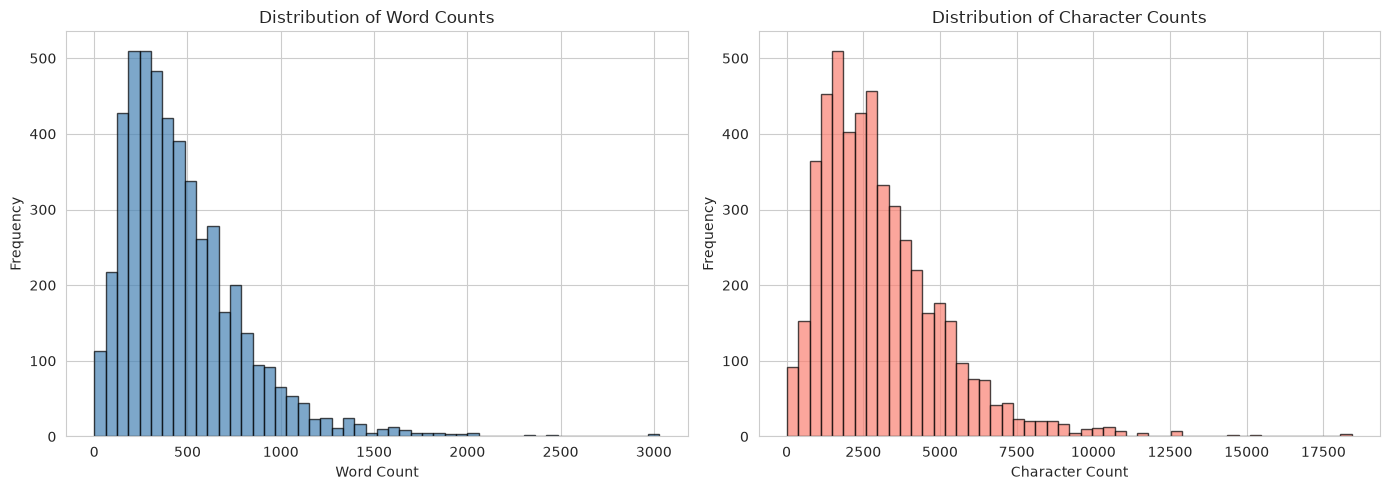

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['word_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Word Counts')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['char_count'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Character Counts')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [19]:
from collections import Counter

# Most common words across all transcriptions
all_words = ' '.join(df_clean['transcription_processed']).split()
word_freq = Counter(all_words)

print("Top 30 most common words:")
print("-" * 40)
for word, count in word_freq.most_common(30):
    print(f"{word:20s}: {count}")

Top 30 most common words:
----------------------------------------
patient             : 22174
right               : 11148
left                : 10812
placed              : 6968
normal              : 6890
well                : 5937
pain                : 5672
also                : 4321
using               : 4061
time                : 3992
noted               : 3935
performed           : 3875
blood               : 3834
without             : 3730
incision            : 3562
used                : 3529
removed             : 3492
room                : 3442
skin                : 3435
artery              : 2942
anterior            : 2898
yearold             : 2847
taken               : 2805
date                : 2687
back                : 2554
position            : 2530
area                : 2491
lower               : 2442
disease             : 2413
two                 : 2384


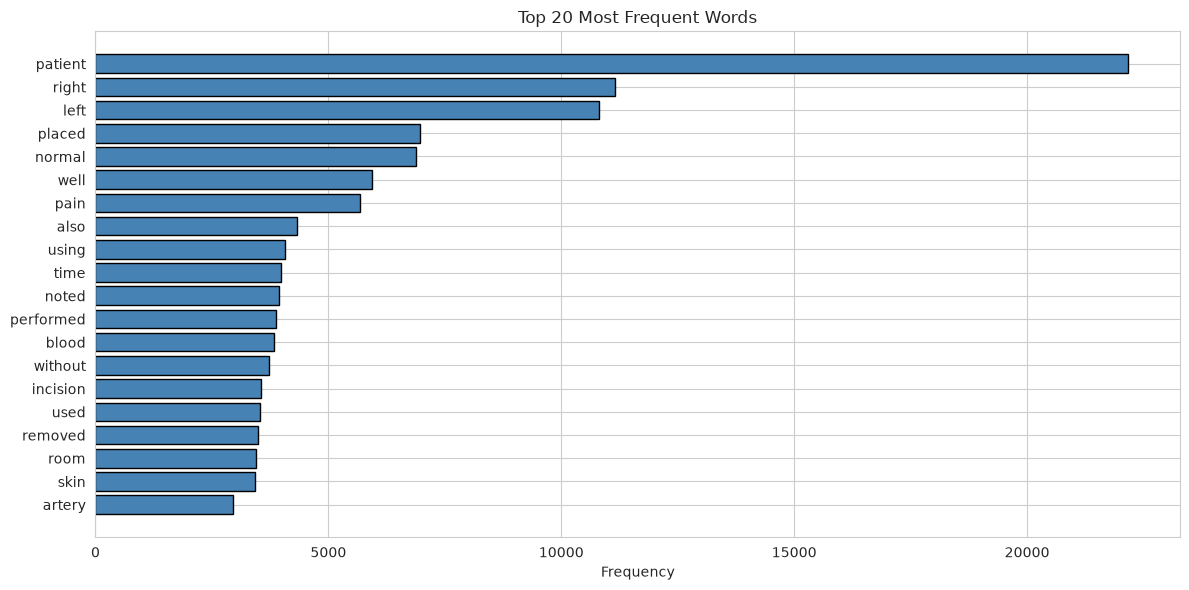

In [20]:
# Plot top 20 words
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.barh(range(len(words)), counts, color='steelblue', edgecolor='black')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

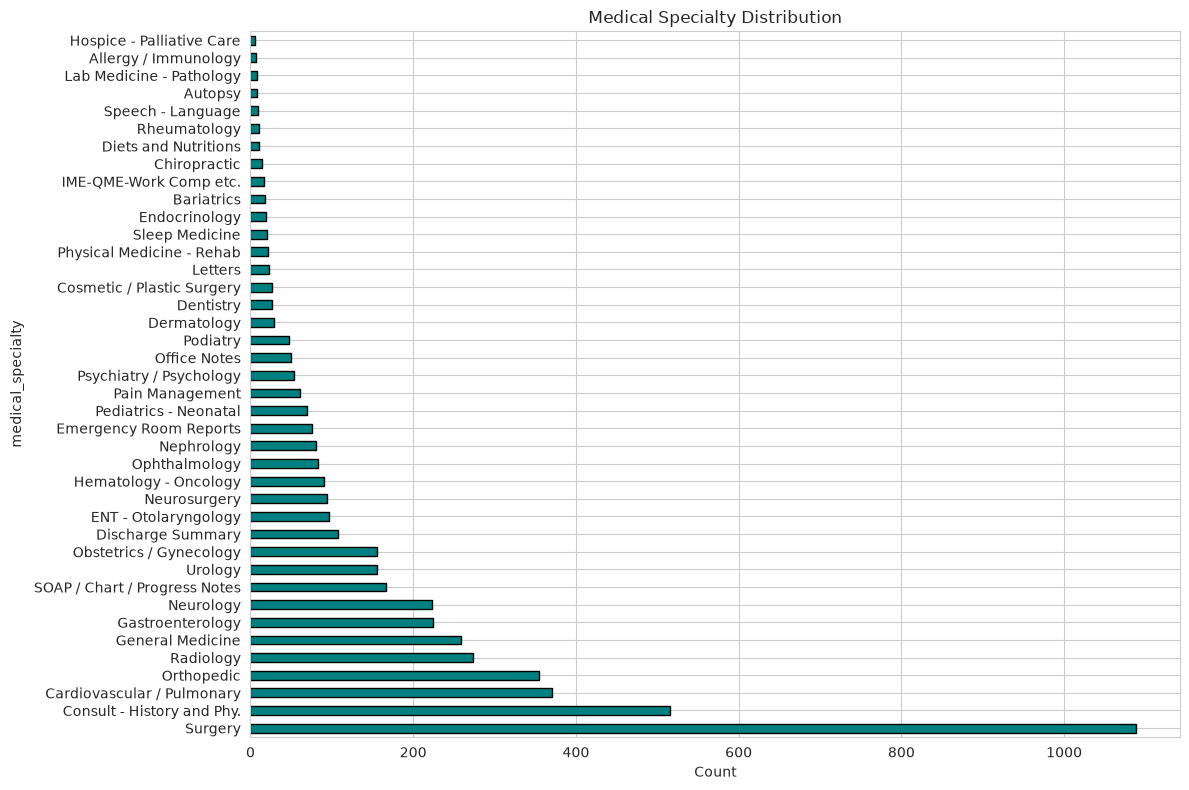

In [21]:
plt.figure(figsize=(12, 8))
specialty_counts = df_clean['medical_specialty'].value_counts()
specialty_counts.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Count')
plt.title('Medical Specialty Distribution')
plt.tight_layout()
plt.show()

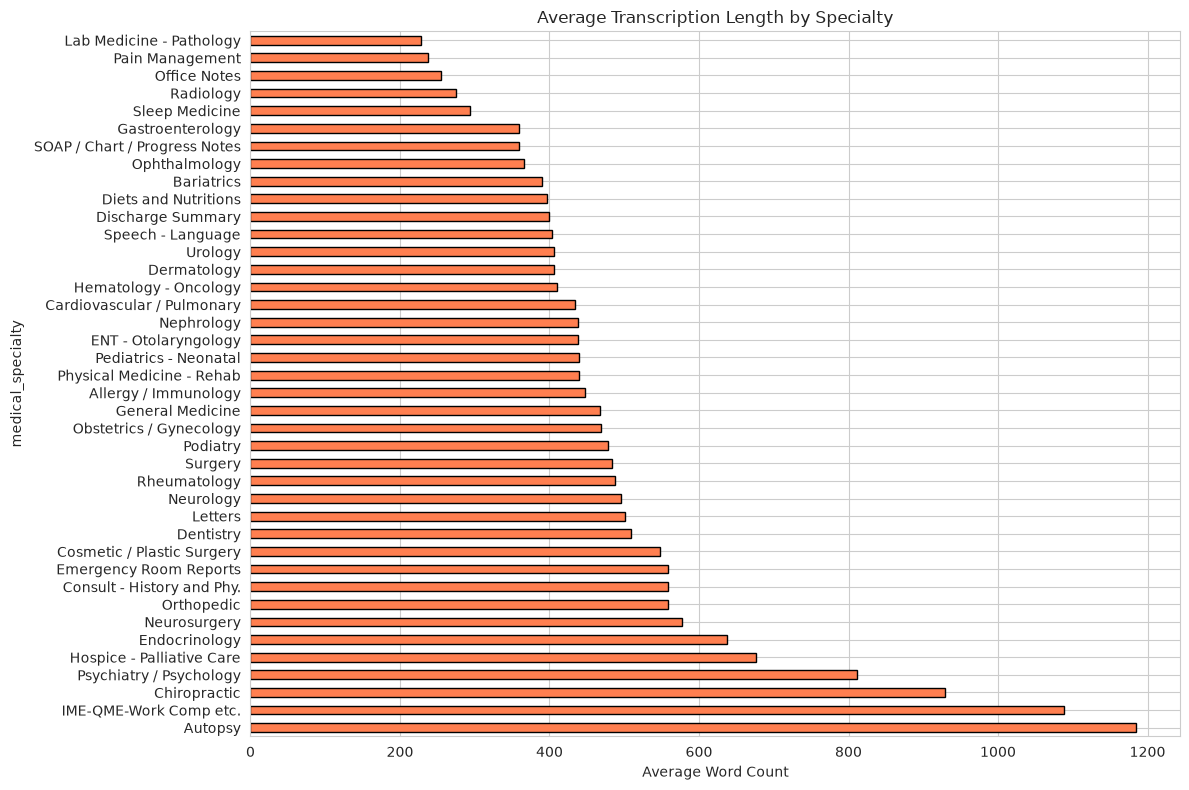

In [22]:
# Average word count by specialty
avg_words = df_clean.groupby('medical_specialty')['word_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
avg_words.plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Average Word Count')
plt.title('Average Transcription Length by Specialty')
plt.tight_layout()
plt.show()

In [23]:
from wordcloud import WordCloud

all_text = ' '.join(df_clean['transcription_processed'])

wordcloud = WordCloud(width=1200, height=600, background_color='white', 
                      max_words=100, colormap='viridis').generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Medical Transcriptions', fontsize=16)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
tfidf_matrix = tfidf.fit_transform(df_clean['transcription_processed'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF matrix shape: (4966, 5000)
Vocabulary size: 5000


In [ ]:
# Additional text features
df_clean['unique_word_count'] = df_clean['transcription_processed'].apply(lambda x: len(set(x.split())))
df_clean['avg_word_length'] = df_clean['transcription_processed'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)
df_clean['sentence_count'] = df_clean['transcription'].apply(lambda x: len(str(x).split('.')))

print("Engineered features:")
print(df_clean[['word_count', 'unique_word_count', 'avg_word_length', 'sentence_count']].describe())

Engineered features:
        word_count  unique_word_count  avg_word_length  sentence_count
count  4966.000000        4966.000000      4966.000000     4966.000000
mean    465.448852         166.691905         7.212009       45.619211
std     316.386344          93.276985         0.535359       29.000146
min       1.000000           0.000000         0.000000        1.000000
25%     241.000000          97.000000         6.935083       24.000000
50%     398.000000         152.000000         7.190343       39.000000
75%     615.000000         220.000000         7.458213       61.000000
max    3029.000000         705.000000        13.250000      244.000000


In [ ]:
# Top TF-IDF terms
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()

top_indices = mean_tfidf.argsort()[-20:][::-1]
top_features = [(feature_names[i], mean_tfidf[i]) for i in top_indices]

print("Top 20 TF-IDF terms:")
print("-" * 40)
for word, score in top_features:
    print(f"{word:20s}: {score:.4f}")

Top 20 TF-IDF terms:
----------------------------------------
patient             : 0.0610
right               : 0.0397
left                : 0.0381
normal              : 0.0306
placed              : 0.0266
pain                : 0.0263
well                : 0.0212
using               : 0.0183
without             : 0.0180
also                : 0.0175
noted               : 0.0173
blood               : 0.0169
time                : 0.0169
incision            : 0.0162
performed           : 0.0160
room                : 0.0158
used                : 0.0158
removed             : 0.0157
date                : 0.0157
skin                : 0.0156


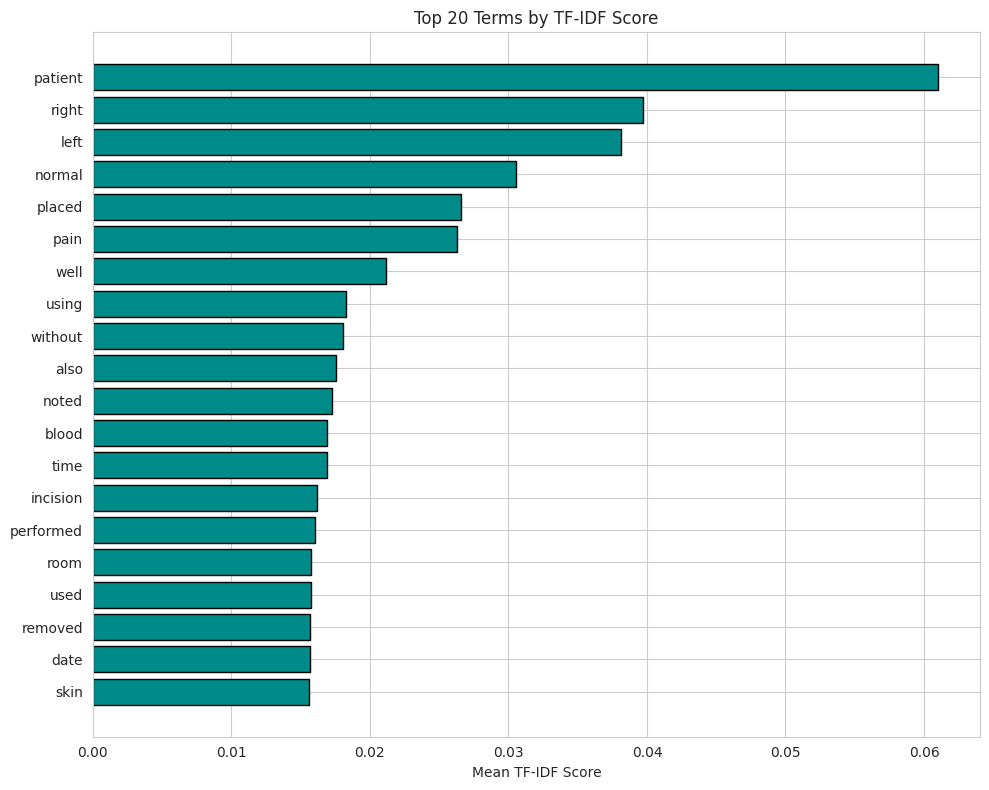

In [ ]:
# Plot top TF-IDF terms
words, scores = zip(*top_features)

plt.figure(figsize=(10, 8))
plt.barh(range(len(words)), scores, color='darkcyan', edgecolor='black')
plt.yticks(range(len(words)), words)
plt.xlabel('Mean TF-IDF Score')
plt.title('Top 20 Terms by TF-IDF Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize text into sequences
MAX_WORDS = 10000
MAX_LEN = 500

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(df_clean['transcription_processed'])

sequences = keras_tokenizer.texts_to_sequences(df_clean['transcription_processed'])

print(f"Vocabulary size: {len(keras_tokenizer.word_index)}")
print(f"Number of sequences: {len(sequences)}")
print(f"Sample sequence (first 20 tokens): {sequences[0][:20]}")

I0000 00:00:1789313854.581647   28447 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789313854.607374   28447 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789313855.363796   28447 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Vocabulary size: 33948
Number of sequences: 4966
Sample sequence (first 20 tokens): [23, 173, 110, 471, 335, 17, 5261, 9852, 2542, 795, 121, 1607, 3487, 3256, 1385, 812, 11, 1553, 3437, 1]


In [ ]:
# Pad sequences to uniform length
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Padded sequences shape: {X_padded.shape}")
print(f"dtype: {X_padded.dtype}")
print(f"Sample padded sequence (first 30 values): {X_padded[0][:30]}")

Padded sequences shape: (4966, 500)
dtype: int32
Sample padded sequence (first 30 values): [  23  173  110  471  335   17 5261 9852 2542  795  121 1607 3487 3256
 1385  812   11 1553 3437    1   17 3630    9   17  133 5140  581   10
   31  145]


In [ ]:
# Encode target labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_clean['medical_specialty'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Classes: {list(label_encoder.classes_)}")
print(f"Encoded labels shape: {y_encoded.shape}")

Number of classes: 40
Classes: [' Allergy / Immunology', ' Autopsy', ' Bariatrics', ' Cardiovascular / Pulmonary', ' Chiropractic', ' Consult - History and Phy.', ' Cosmetic / Plastic Surgery', ' Dentistry', ' Dermatology', ' Diets and Nutritions', ' Discharge Summary', ' ENT - Otolaryngology', ' Emergency Room Reports', ' Endocrinology', ' Gastroenterology', ' General Medicine', ' Hematology - Oncology', ' Hospice - Palliative Care', ' IME-QME-Work Comp etc.', ' Lab Medicine - Pathology', ' Letters', ' Nephrology', ' Neurology', ' Neurosurgery', ' Obstetrics / Gynecology', ' Office Notes', ' Ophthalmology', ' Orthopedic', ' Pain Management', ' Pediatrics - Neonatal', ' Physical Medicine - Rehab', ' Podiatry', ' Psychiatry / Psychology', ' Radiology', ' Rheumatology', ' SOAP / Chart / Progress Notes', ' Sleep Medicine', ' Speech - Language', ' Surgery', ' Urology']
Encoded labels shape: (4966,)


In [ ]:
# Final model-ready tensors
X_tensor = X_padded.astype(np.float32)
y_tensor = y_encoded.astype(np.float32)

print(f"Final X tensor: {X_tensor.shape}, dtype={X_tensor.dtype}")
print(f"Final y tensor: {y_tensor.shape}, dtype={y_tensor.dtype}")

Final X tensor: (4966, 500), dtype=float32
Final y tensor: (4966,), dtype=float32


In [ ]:
# Compare before and after preprocessing
print("=" * 60)
print("BEFORE preprocessing:")
print(df_clean.iloc[0]['transcription'][:300])
print("\n" + "=" * 60)
print("AFTER preprocessing:")
print(df_clean.iloc[0]['transcription_processed'][:300])

BEFORE preprocessing:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has us

AFTER preprocessing:
yearold white female presents complaint used lived seattle thinks worse past tried claritin zyrtec worked short time seemed lose effectiveness used allegra also used last summer began using two weeks ago appear working well used overthecounter sprays prescription nasal sprays asthma doest require da
